In [1]:
import pandas as pd
import numpy as np
data = pd.read_csv(r"/content/predicting house price.csv")

In [2]:
data.head()

,Location,Size (sqft),Bedrooms,Bathrooms,Year Built,Condition,Price
0,Suburban,1295,5,1,2007,5,61023
1,Urban,1163,1,3,1961,1,216619
2,Urban,2020,1,2,1983,5,168012
3,Suburban,1279,2,1,2004,1,206542
4,Urban,2268,1,1,1961,2,316979


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Location     1000 non-null   object
 1   Size (sqft)  1000 non-null   int64 
 2   Bedrooms     1000 non-null   int64 
 3   Bathrooms    1000 non-null   int64 
 4   Year Built   1000 non-null   int64 
 5   Condition    1000 non-null   int64 
 6   Price        1000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 54.8+ KB


In [4]:
data.isna().sum()

,0
Location,0
Size (sqft),0
Bedrooms,0
Bathrooms,0
Year Built,0
Condition,0
Price,0


In [5]:
from sklearn.preprocessing import LabelEncoder
cat_columns = ["Location"]
le = {}
for col in cat_columns:
    encoder = LabelEncoder()
    data[col] = encoder.fit_transform(data[col])
    le[col] = encoder

In [6]:
data.head()

,Location,Size (sqft),Bedrooms,Bathrooms,Year Built,Condition,Price
0,1,1295,5,1,2007,5,61023
1,2,1163,1,3,1961,1,216619
2,2,2020,1,2,1983,5,168012
3,1,1279,2,1,2004,1,206542
4,2,2268,1,1,1961,2,316979


In [7]:
from sklearn.preprocessing import StandardScaler
num_columns = ["Size (sqft)" , "Bedrooms" , "Bathrooms" , "Year Built" , "Condition"]
scale = StandardScaler()
data[num_columns] = scale.fit_transform(data[num_columns])

In [8]:
data.head()

,Location,Size (sqft),Bedrooms,Bathrooms,Year Built,Condition,Price
0,1,-1.067816,1.729282,-1.231835,1.040608,1.255999,61023
1,2,-1.240099,-1.235625,1.256721,-1.133331,-1.397988,216619
2,2,-0.121569,-1.235625,0.012443,-0.093621,1.255999,168012
3,1,-1.088699,-0.494398,-1.231835,0.898830,-1.397988,206542
4,2,0.202113,-1.235625,-1.231835,-1.133331,-0.734491,316979


In [9]:
summary = data.describe()
print(summary)

          Location   Size (sqft)      Bedrooms     Bathrooms    Year Built  \
count  1000.000000  1.000000e+03  1.000000e+03  1.000000e+03  1.000000e+03   
mean      1.020000  2.913225e-16  9.769963e-17  4.618528e-17  2.664535e-16   
std       0.815024  1.000500e+00  1.000500e+00  1.000500e+00  1.000500e+00   
min       0.000000 -1.981435e+00 -1.235625e+00 -1.231835e+00 -1.653187e+00   
25%       0.000000 -7.506603e-01 -1.235625e+00 -1.231835e+00 -9.442932e-01   
50%       1.000000 -5.631023e-02  2.468285e-01  1.244278e-02 -9.362118e-02   
75%       2.000000  8.142377e-01  9.880552e-01  1.256721e+00  8.988295e-01   
max       2.000000  1.780063e+00  1.729282e+00  1.256721e+00  1.607723e+00   

          Condition          Price  
count  1.000000e+03    1000.000000  
mean  -6.394885e-17  282989.120000  
std    1.000500e+00  130220.566705  
min   -1.397988e+00   54748.000000  
25%   -7.344908e-01  172402.000000  
50%   -7.099414e-02  309747.000000  
75%    1.255999e+00  391003.000000  
m

Text(0.5, 1.0, 'Distribution of home price')

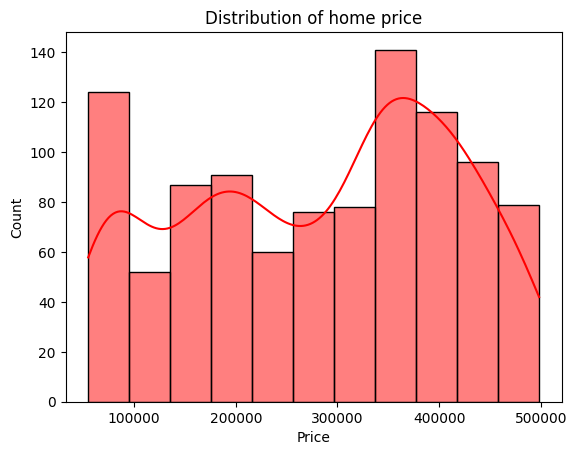

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data["Price"] , color = "red" , kde = True)
plt.title("Distribution of home price")

Text(0.5, 1.0, 'relation between price and home size')

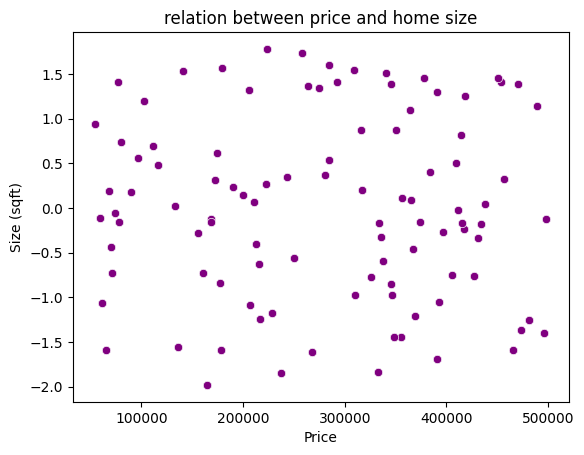

In [13]:
sns.scatterplot(data = data , x = "Price" , y = "Size (sqft)" , color = "purple")
plt.title("relation between price and home size")

Text(0.5, 1.0, 'chart to show how location impact on pice')

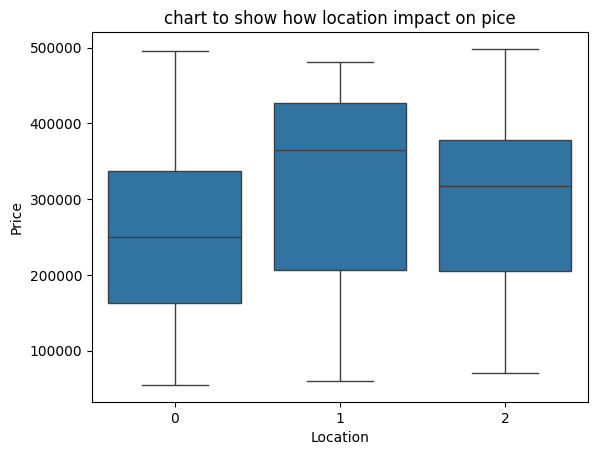

In [14]:
sns.boxplot(data = data , x = "Location" , y = "Price" )
plt.title("chart to show how location impact on pice")

In [15]:
from sklearn.model_selection import train_test_split
x = data.drop("Price" , axis = 1)
y = data["Price"]
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.2 , random_state = 42)

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score
lr = LinearRegression()
lr.fit(x_train , y_train)
lr_y_pred = lr.predict(x_test)
print("MAE = " ,  mean_absolute_error(y_test , lr_y_pred))
print("MSE = " ,  mean_squared_error(y_test , lr_y_pred))
print("R2_score" , r2_score(y_test , lr_y_pred))

MAE =  109912.47385351837
MSE =  15770483148.400627
R2_score 0.06591055803266965


In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score
rf = RandomForestRegressor()
rf.fit(x_train , y_train)
rf_y_pred = rf.predict(x_test)
print("MAE = " ,  mean_absolute_error(y_test , rf_y_pred))
print("MSE = " ,  mean_squared_error(y_test , rf_y_pred))
print("R2_score" , r2_score(y_test , rf_y_pred))

MAE =  524.1330499999992
MSE =  2870839.0720254956
R2_score 0.9998299595236536


In [18]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score
dt = DecisionTreeRegressor()
dt.fit(x_train , y_train)
dt_y_pred = dt.predict(x_test)
print("MAE = " ,  mean_absolute_error(y_test , dt_y_pred))
print("MSE = " ,  mean_squared_error(y_test , dt_y_pred))
print("R2_score" , r2_score(y_test , dt_y_pred))

MAE =  0.0
MSE =  0.0
R2_score 1.0


In [19]:
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV
grid_params = {
    "max_depth" : [x for x in range(25,70)],
    "max_leaf_nodes" : [x for x in range(30,50)],
}
grid_model = GridSearchCV(DecisionTreeRegressor() , grid_params , cv = 5)
grid_model.fit(x_train , y_train)
print(grid_model.best_params_)
print(grid_model.best_score_)

{'max_depth': 25, 'max_leaf_nodes': 49}
0.9716548671115207


In [20]:
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV
random_params = {
    "max_depth" : [x for x in range(25,70)],
    "n_estimators" : [x for x in range(30,50)],
}
random_model = RandomizedSearchCV(RandomForestRegressor() , random_params , cv = 5)
random_model.fit(x_train , y_train)
print(random_model.best_estimator_)
print(random_model.best_score_)

RandomForestRegressor(max_depth=39, n_estimators=32)
0.9979654820852784


<Axes: xlabel='Price'>

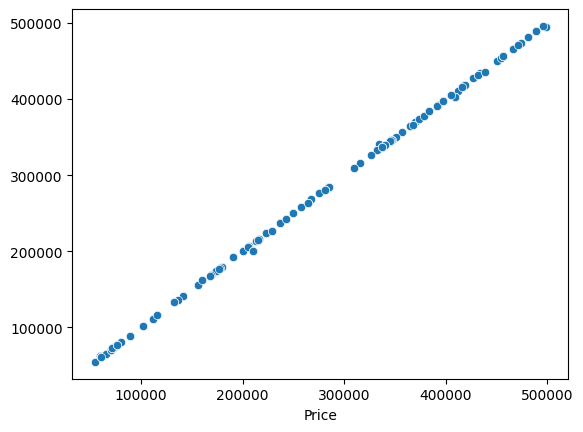

In [21]:
sns.scatterplot(x = y_test , y = rf_y_pred)

In [22]:
data.columns

Index(['Location', 'Size (sqft)', 'Bedrooms', 'Bathrooms', 'Year Built',
       'Condition', 'Price'],
      dtype='object')

In [23]:
def predict(Location , Size_sqft , Bedrooms , Bathrooms , Year_Built , Condition):
    try:
        input_data = pd.DataFrame({
            "Location" : [Location],
            "Size (sqft)" : [Size_sqft],
            "Bedrooms" : [Bedrooms],
            "Bathrooms" : [Bathrooms],
            "Year Built" : [Year_Built],
            "Condition" : [Condition],
        })
        for sol in cat_columns:
            input_data[col] = le[col].transform(input_data[col])
        input_data[num_columns] = scale.transform(input_data[num_columns])
        prediction = rf.predict(input_data)[0]
        return f"house price is : {prediction}"
    except Exception as e:
        return f"error {e}"

In [24]:
import gradio as gr
gr.Interface(
    fn = predict,
    inputs = [
        gr.Dropdown(label = "Location" , choices = ["Rural" , "Suburban" , "Urban"]),
        gr.Number(label = "Size_sqft"),
        gr.Number(label = "Bedrooms"),
        gr.Number(label = "Bathrooms"),
        gr.Number(label = "Year_Built"),
        gr.Number(label = "Condition"),
    ],
    outputs = "text",
    title = "predicting house price",
).launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://88df28b5b002121a78.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
